# Chapter 4 — Classification Algorithms
## 4.1 Logistic Regression + 4.2 K-Nearest Neighbors

**Dataset:** Pima Indians Diabetes (768 patients, 8 features)  
**Goal:** Predict whether a patient has diabetes (binary classification)  
**Algorithms covered:** Logistic Regression (baseline) · KNN from scratch · sklearn KNN · K-tuning · Comparison

---

## 4.1 Logistic Regression — Concept Summary

### What is it?
Despite the name "regression", Logistic Regression is a **classification** algorithm. It predicts the **probability** that a data point belongs to a class, then applies a threshold to make a decision.

### The sigmoid function
The core idea: take any number z and squash it to a value between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### How z is calculated
$$z = w_1 \times feature_1 + w_2 \times feature_2 + \dots + bias$$

- **w1, w2...** = weights — importance scores for each feature, learned automatically by the model during training
- **bias** = a fixed starting offset, also learned automatically
- You never set these manually — `model.fit()` learns them via gradient descent

### Decision rule
- If p ≥ 0.5 → predict class 1 (Diabetic)
- If p < 0.5 → predict class 0 (Healthy)
- Lower the threshold (e.g. 0.3) when false negatives are very costly (e.g. cancer detection)

### Why not Linear Regression for classification?
Linear Regression outputs unbounded numbers (e.g. −0.5, 1.8). Probabilities must stay between 0 and 1. The sigmoid function enforces this constraint.

### When to use Logistic Regression
- Binary classification (Yes/No, Spam/Ham)
- You need probability scores, not just class labels
- Data is roughly linearly separable
- You want a fast, interpretable baseline
- **Always StandardScale features before use**

---

## 4.2 KNN — K-Nearest Neighbors — Concept Summary

### What is it?
KNN is a **lazy learner** — it has no training phase. It memorises the entire training dataset and does all work at prediction time.

**Analogy:** You move to a new city. To decide if a neighbourhood is safe, you simply ask your 5 nearest neighbours. 4 say safe → you conclude: safe. That is KNN.

### How it works (step by step)
1. Store all training data
2. New point arrives → calculate distance to every stored training point
3. Sort by distance — pick the K closest
4. Majority vote among K neighbours → predicted class

### Distance formulas
**Euclidean (default):** $d = \sqrt{\sum(a_i - b_i)^2}$ — straight-line distance  
**Manhattan:** $d = \sum|a_i - b_i|$ — grid-path distance, better with outliers

### Effect of K
- K too small (K=1) → overfits — jagged boundary, memorises noise
- K too large (K=100) → underfits — too smooth, misses real patterns
- Sweet spot: K=5–15, always odd for binary classification (avoids ties)
- Use cross-validation or a K-accuracy plot to find the best K

### Why scaling is mandatory
KNN uses distance. Features with large units (e.g. income in ₹50,000) dominate features with small units (e.g. num_loans = 2). StandardScaler brings all features to mean=0, std=1 so none bullies the others.

**Rule:** Any distance-based algorithm (KNN, SVM, Logistic Regression) needs scaling. Tree models (Decision Tree, Random Forest) do not.

---

## Part 1 — Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

print('All imports successful!')

All imports successful!


## Part 2 — Load and Explore the Dataset

In [2]:
# diabetes.csv must be in the same folder as this notebook
df = pd.read_csv('diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [4]:
print('Class distribution (Outcome):')
print(df['Outcome'].value_counts())
print('\nAs percentage:')
print(df['Outcome'].value_counts(normalize=True).round(2) * 100)

Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

As percentage:
Outcome
0    65.0
1    35.0
Name: proportion, dtype: float64


In [5]:
print('Statistical summary:')
df.describe().round(2)

Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
# Check hidden zeros — medically impossible values treated as missing
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts (= hidden missing values):')
print((df[zero_cols] == 0).sum())

Zero counts (= hidden missing values):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [7]:
# Fix: replace zeros with column median (same technique from Chapter 2)
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

print('Zeros after fix:')
print((df[zero_cols] == 0).sum())

Zeros after fix:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Outlier Sensitivity: Because the formula uses the Mean, a single crazy outlier (like a 900 Insulin reading) can totally warp the correlation score.

Linear Only: The math assumes the relationship is a straight line. If your data looks like a curve (e.g., as temperature goes up, ice cream sales go up, but then drop when it gets too hot), corr() will give you a low score even though there is a very clear pattern.

In [ ]:
# Correlation with target
#By default, df.corr() uses the Pearson Correlation Coefficient
corr = df.corr()['Outcome'].sort_values(ascending=False)
print('Correlation with Outcome (diabetic):')
print(corr.round(3))
# 4. A Small Warning

# Correlation only measures linear relationships (straight lines).

# Example: If you have a feature where the risk is low when the value is low, high in the middle, and low again when it's high (a "U" shape), df.corr() might say 0, even though there is a relationship.

# Since you've already replaced those "hidden zeros" with the Median, your correlation scores will now be much more accurate!

Correlation with Outcome (diabetic):
Outcome                     1.000
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.189
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Insulin                     0.148
Name: Outcome, dtype: float64


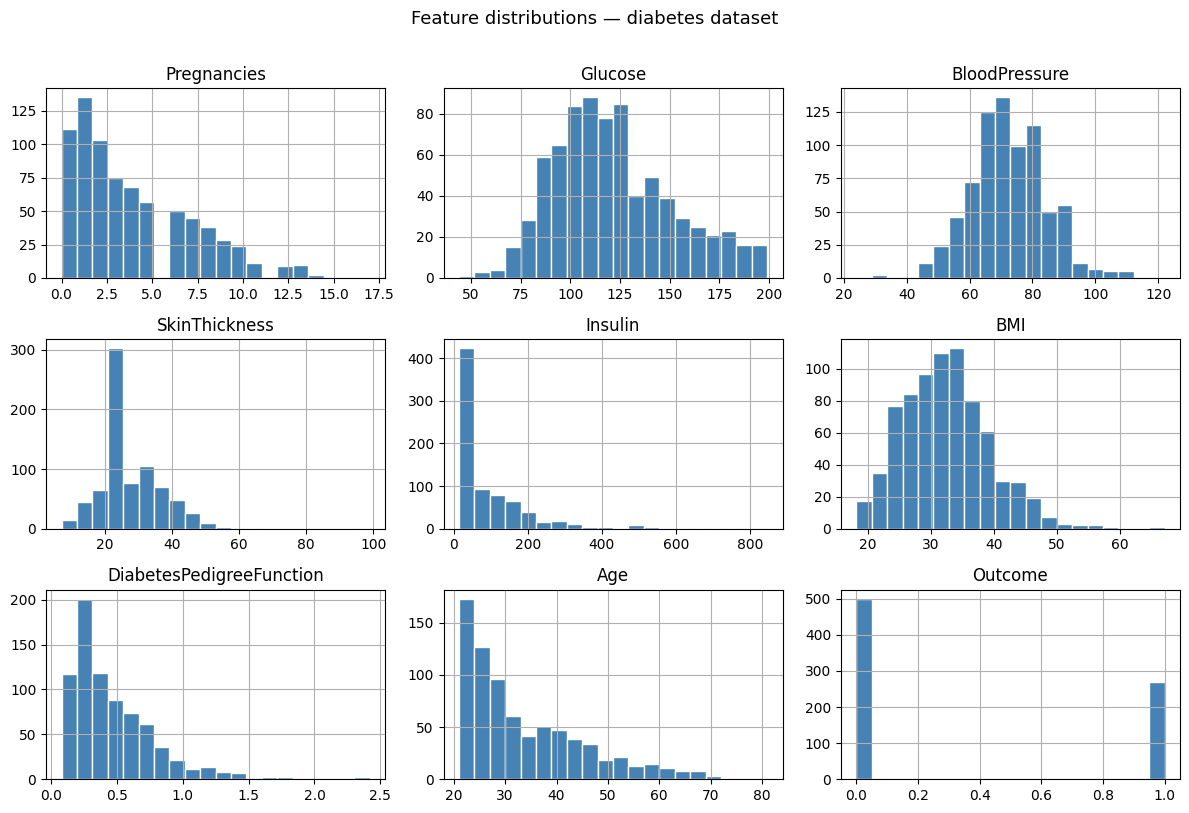

In [9]:
# Feature distributions
df.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Feature distributions — diabetes dataset', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Part 3 — KNN from Scratch (Pure Python)

We build KNN manually to understand exactly what happens inside.
Using only 2 features (Glucose + BMI) so we can visualise clearly.

In [10]:
# Use only 2 features for the scratch version
X_scratch = df[['Glucose', 'BMI']].values
y_scratch  = df['Outcome'].values

print('X shape:', X_scratch.shape)
print('y shape:', y_scratch.shape)
print('\nFirst 3 patients:')
for i in range(3):
    label = 'Diabetic' if y_scratch[i] == 1 else 'Healthy'
    print(f'  Glucose={X_scratch[i,0]:.1f}, BMI={X_scratch[i,1]:.1f} → {label}')

X shape: (768, 2)
y shape: (768,)

First 3 patients:
  Glucose=148.0, BMI=33.6 → Diabetic
  Glucose=85.0, BMI=26.6 → Healthy
  Glucose=183.0, BMI=23.3 → Diabetic


In [11]:
# SCALE FIRST — KNN is distance-based, scaling is mandatory
scaler_scratch = StandardScaler()
X_scaled = scaler_scratch.fit_transform(X_scratch)

print('BEFORE scaling:')
print(f'  Glucose — mean: {X_scratch[:,0].mean():.1f}, std: {X_scratch[:,0].std():.1f}')
print(f'  BMI     — mean: {X_scratch[:,1].mean():.1f}, std: {X_scratch[:,1].std():.1f}')
print('\nAFTER scaling:')
print(f'  Glucose — mean: {X_scaled[:,0].mean():.2f}, std: {X_scaled[:,0].std():.2f}')
print(f'  BMI     — mean: {X_scaled[:,1].mean():.2f}, std: {X_scaled[:,1].std():.2f}')
print('\n→ Mean=0, Std=1 for both features. Neither dominates the distance calculation.')

BEFORE scaling:
  Glucose — mean: 121.7, std: 30.4
  BMI     — mean: 32.5, std: 6.9

AFTER scaling:
  Glucose — mean: 0.00, std: 1.00
  BMI     — mean: 0.00, std: 1.00

→ Mean=0, Std=1 for both features. Neither dominates the distance calculation.


2. Breaking down the code

scaler_scratch = StandardScaler()

You are initializing the tool. Think of this as buying a specialized "data-shrinking machine" and plugging it in.

scaler_scratch.fit(X_scratch)

The .fit() part is the "Learning Phase." The scaler looks at your data and calculates the Mean and Standard Deviation for every column. It memorizes these values. It hasn't changed your data yet; it’s just doing the prep work.

scaler_scratch.transform(X_scratch)

The .transform() part is the "Action Phase." It applies the formula above to every number in X_scratch.

If a value was exactly average, it becomes 0.

If it was higher than average, it becomes a positive number (usually between 1 and 3).

If it was lower than average, it becomes a negative number.

.fit_transform()

This is just a shortcut. It does both steps at the same time to save you a line of code.

3. Why is this mandatory for Logistic Regression?

Logistic Regression relies on Gradient Descent (an optimization math trick) to find the best "line" to separate your classes.

If your features have wildly different scales:

The "Slow Lane": The math has to work much harder to find the solution. It’s like trying to run a race where one leg is 5 feet long and the other is 2 inches long—you'll just spin in circles.

Model Bias: The model will "over-prioritize" the columns with large numbers (like Insulin) and ignore the small ones (like DiabetesPedigreeFunction), even if the small ones are actually more important for predicting diabetes.

In [12]:
# Step 1: Euclidean distance from scratch
def euclidean_distance(point1, point2):
    """
    Straight-line distance between two patients.
    Formula: sqrt( sum of (a - b)^2 for each feature )
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))


# Test manually
priya = np.array([1.2,  0.8])   # high glucose, high BMI
ravi  = np.array([1.3,  0.9])   # very similar to Priya
meena = np.array([-1.0, -0.5])  # low glucose, low BMI

d1 = euclidean_distance(priya, ravi)
d2 = euclidean_distance(priya, meena)

print(f'Priya → Ravi  : {d1:.4f}  (close)')
print(f'Priya → Meena : {d2:.4f}  (far)')
print(f'Ravi is closer to Priya? {d1 < d2}')

Priya → Ravi  : 0.1414  (close)
Priya → Meena : 2.5554  (far)
Ravi is closer to Priya? True


In [13]:
# Step 2: Full KNN classifier from scratch
def knn_predict_one(X_train, y_train, test_point, k=5):
    """
    Predict class for ONE test patient.

    Step 1: measure distance from test_point to every training patient
    Step 2: sort — smallest distance first
    Step 3: take top K neighbours
    Step 4: majority vote → return winning class
    """
    # Step 1: distances to all training points
    distances = []
    for i in range(len(X_train)):
        dist  = euclidean_distance(test_point, X_train[i])
        label = y_train[i]
        distances.append((dist, label))

    # Step 2: sort by distance, closest first
    distances.sort(key=lambda x: x[0])

    # Step 3: take K nearest
    k_nearest = distances[:k]

    # Step 4: majority vote
    labels  = [label for (dist, label) in k_nearest]
    votes_1 = labels.count(1)
    votes_0 = labels.count(0)

    return 1 if votes_1 > votes_0 else 0


# Test on one real patient
test_patient = X_scaled[0]
actual_label = y_scratch[0]
prediction   = knn_predict_one(X_scaled[1:], y_scratch[1:], test_patient, k=5)

print(f'Patient (scaled): Glucose={test_patient[0]:.3f}, BMI={test_patient[1]:.3f}')
print(f'Actual   : {"Diabetic" if actual_label==1 else "Healthy"}')
print(f'Predicted: {"Diabetic" if prediction==1 else "Healthy"}')
print(f'Correct  : {prediction == actual_label}')

Patient (scaled): Glucose=0.866, BMI=0.167
Actual   : Diabetic
Predicted: Healthy
Correct  : False


In [14]:
# Run scratch KNN on full test set (manual 80/20 split)
split     = int(0.8 * len(X_scaled))
X_train_s = X_scaled[:split]
X_test_s  = X_scaled[split:]
y_train_s = y_scratch[:split]
y_test_s  = y_scratch[split:]

print(f'Training on {len(X_train_s)} patients, testing on {len(X_test_s)} patients')
print('Running scratch KNN... (may take 10-20 seconds)')

predictions_scratch = []
for i in range(len(X_test_s)):
    pred = knn_predict_one(X_train_s, y_train_s, X_test_s[i], k=5)
    predictions_scratch.append(pred)

predictions_scratch = np.array(predictions_scratch)
correct  = np.sum(predictions_scratch == y_test_s)
accuracy = correct / len(y_test_s)

print(f'\nScratch KNN Accuracy (k=5, 2 features): {accuracy:.2%}')
print(f'Correct  : {correct} / {len(y_test_s)}')
print(f'Wrong    : {len(y_test_s) - correct} / {len(y_test_s)}')

Training on 614 patients, testing on 154 patients
Running scratch KNN... (may take 10-20 seconds)

Scratch KNN Accuracy (k=5, 2 features): 64.94%
Correct  : 100 / 154
Wrong    : 54 / 154


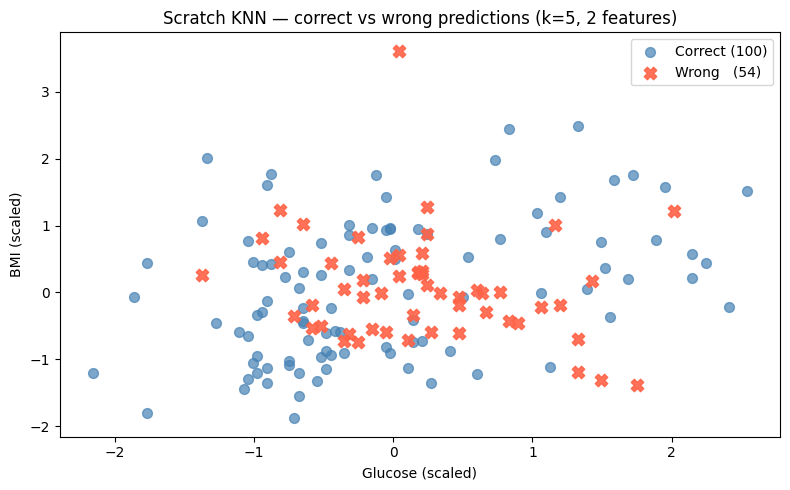

Most wrong predictions appear near the decision boundary (middle of the plot)


In [15]:
# Visualise: correct vs wrong predictions
correct_mask   = predictions_scratch == y_test_s
incorrect_mask = ~correct_mask

plt.figure(figsize=(8, 5))
plt.scatter(X_test_s[correct_mask,   0], X_test_s[correct_mask,   1],
            c='steelblue', label=f'Correct ({correct_mask.sum()})', alpha=0.7, s=50)
plt.scatter(X_test_s[incorrect_mask, 0], X_test_s[incorrect_mask, 1],
            c='tomato',    label=f'Wrong   ({incorrect_mask.sum()})', alpha=0.9, s=80, marker='X')
plt.xlabel('Glucose (scaled)')
plt.ylabel('BMI (scaled)')
plt.title('Scratch KNN — correct vs wrong predictions (k=5, 2 features)')
plt.legend()
plt.tight_layout()
plt.show()
print('Most wrong predictions appear near the decision boundary (middle of the plot)')

## Part 4 — Proper sklearn KNN (All 8 Features)

Scratch version used 2 features. Now we use all 8 with a proper train/test split and correct scaling pipeline.

In [16]:
# Prepare full feature set
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print('Features used:', X.columns.tolist())
print('X shape:', X.shape)
print('y shape:', y.shape)

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X shape: (768, 8)
y shape: (768,)


In [17]:
# Golden rule: split FIRST, then scale
# stratify=y preserves class ratio in both train and test (important for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} patients')
print(f'Test : {X_test.shape[0]} patients')
print(f'\nClass ratio in train: {y_train.value_counts(normalize=True).round(2).to_dict()}')
print(f'Class ratio in test : {y_test.value_counts(normalize=True).round(2).to_dict()}')

Train: 614 patients
Test : 154 patients

Class ratio in train: {0: 0.65, 1: 0.35}
Class ratio in test : {0: 0.65, 1: 0.35}


In [18]:
# Scale — fit on train ONLY, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)         # transform test with train's stats only

print('Scaling done — fit on train only (no data leakage)')

Scaling done — fit on train only (no data leakage)


In [19]:
# Train sklearn KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred      = knn.predict(X_test_scaled)
y_pred_prob = knn.predict_proba(X_test_scaled)[:, 1]

print('=== sklearn KNN (k=5, all 8 features) ===')
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Diabetic']))
print(f'AUC: {roc_auc_score(y_test, y_pred_prob):.3f}')

=== sklearn KNN (k=5, all 8 features) ===
              precision    recall  f1-score   support

     Healthy       0.76      0.81      0.78       100
    Diabetic       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

AUC: 0.761


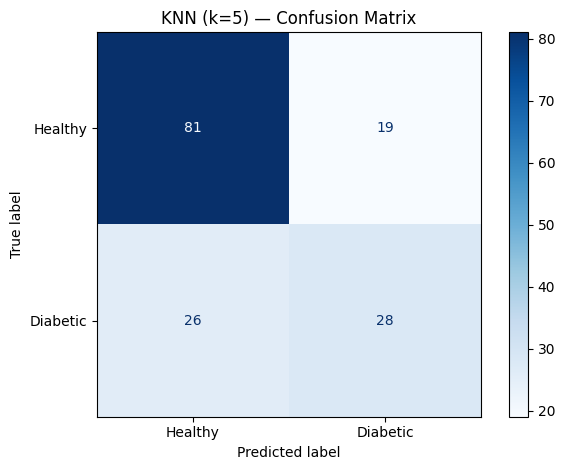

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('KNN (k=5) — Confusion Matrix')
plt.tight_layout()
plt.show()

## Part 5 — Find the Best K

K=5 was a guess. Let's find the best K scientifically by plotting accuracy for every odd K from 1 to 20.

In [21]:
k_values  = list(range(1, 21, 2))   # odd values only: 1,3,5,...,19
accuracies = []
auc_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    acc   = knn_k.score(X_test_scaled, y_test)
    probs = knn_k.predict_proba(X_test_scaled)[:, 1]
    auc   = roc_auc_score(y_test, probs)
    accuracies.append(acc)
    auc_scores.append(auc)
    print(f'K={k:2d} → Accuracy: {acc:.2%}, AUC: {auc:.3f}')

best_k   = k_values[accuracies.index(max(accuracies))]
print(f'\nBest K by accuracy: {best_k} ({max(accuracies):.2%})')

K= 1 → Accuracy: 72.08%, AUC: 0.679
K= 3 → Accuracy: 70.13%, AUC: 0.741
K= 5 → Accuracy: 70.78%, AUC: 0.761
K= 7 → Accuracy: 69.48%, AUC: 0.769
K= 9 → Accuracy: 69.48%, AUC: 0.766
K=11 → Accuracy: 70.78%, AUC: 0.777
K=13 → Accuracy: 71.43%, AUC: 0.783
K=15 → Accuracy: 74.03%, AUC: 0.798
K=17 → Accuracy: 73.38%, AUC: 0.792
K=19 → Accuracy: 74.68%, AUC: 0.796

Best K by accuracy: 19 (74.68%)


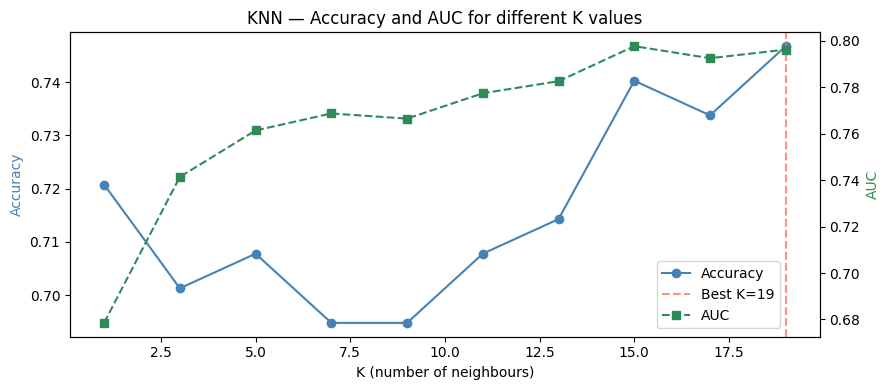

Observation: Small K → overfits. Large K → underfits. Best K = 19


In [22]:
# Plot accuracy curve
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(k_values, accuracies, marker='o', color='steelblue', label='Accuracy')
ax1.set_xlabel('K (number of neighbours)')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.axvline(x=best_k, color='tomato', linestyle='--', alpha=0.7, label=f'Best K={best_k}')

ax2 = ax1.twinx()
ax2.plot(k_values, auc_scores, marker='s', color='seagreen', linestyle='--', label='AUC')
ax2.set_ylabel('AUC', color='seagreen')

plt.title('KNN — Accuracy and AUC for different K values')
fig.legend(loc='lower right', bbox_to_anchor=(0.88, 0.15))
plt.tight_layout()
plt.show()

print(f'Observation: Small K → overfits. Large K → underfits. Best K = {best_k}')

## Part 6 — Compare KNN vs Logistic Regression

Same dataset, same split, same scaling — fair comparison.

In [23]:
# Best KNN
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
knn_pred  = knn_best.predict(X_test_scaled)
knn_probs = knn_best.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print(f'=== KNN (k={best_k}, all 8 features) ===')
print(classification_report(y_test, knn_pred, target_names=['Healthy', 'Diabetic']))
print(f'AUC: {roc_auc_score(y_test, knn_probs):.3f}')

print(f'\n=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['Healthy', 'Diabetic']))
print(f'AUC: {roc_auc_score(y_test, lr_probs):.3f}')

=== KNN (k=19, all 8 features) ===
              precision    recall  f1-score   support

     Healthy       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154

AUC: 0.796

=== Logistic Regression ===
              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

AUC: 0.815


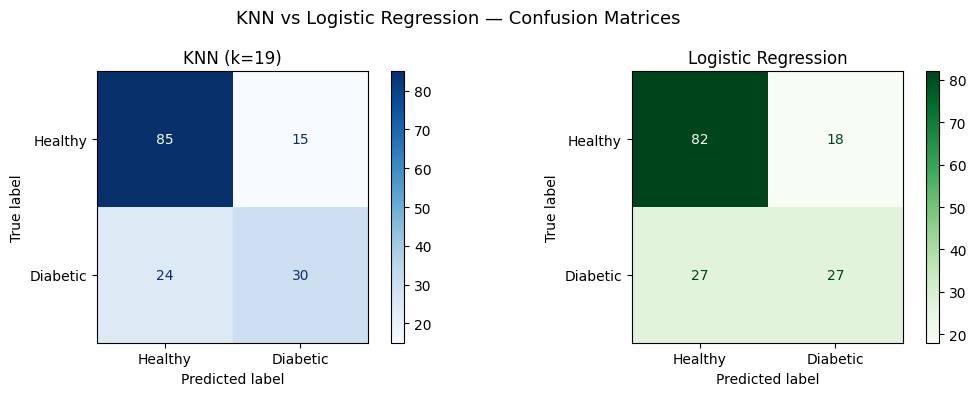

In [24]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, knn_pred),
    display_labels=['Healthy', 'Diabetic']
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'KNN (k={best_k})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_pred),
    display_labels=['Healthy', 'Diabetic']
).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Logistic Regression')

plt.suptitle('KNN vs Logistic Regression — Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Summary comparison table
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model': [f'KNN (k={best_k})', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred)
    ],
    'F1 (Diabetic)': [
        f1_score(y_test, knn_pred),
        f1_score(y_test, lr_pred)
    ],
    'AUC': [
        roc_auc_score(y_test, knn_probs),
        roc_auc_score(y_test, lr_probs)
    ]
}).round(3)

print(results.to_string(index=False))
print('\nKey takeaway: Logistic Regression often wins on small, clean datasets.')
print('KNN shines when decision boundaries are non-linear and data is large.')

              Model  Accuracy  F1 (Diabetic)   AUC
         KNN (k=19)     0.747          0.606 0.796
Logistic Regression     0.708          0.545 0.815

Key takeaway: Logistic Regression often wins on small, clean datasets.
KNN shines when decision boundaries are non-linear and data is large.


## Part 7 — What We Learned (Key Takeaways)

| Topic | Key point |
|---|---|
| Logistic Regression | Uses sigmoid to output probabilities. Learns weights via gradient descent. |
| KNN | No training. Memorises data. Predicts by majority vote of K nearest neighbours. |
| Scaling | Mandatory for both — they use distance/weights sensitive to feature magnitude. |
| Choosing K | Plot accuracy for K=1..20 — pick the elbow. Always use odd K for binary. |
| Scratch vs sklearn | Scratch = understand the math. sklearn = production-ready, fast, full features. |
| KNN weakness | Slow at prediction time — checks every training point for every new prediction. |
| LR vs KNN | LR = faster, more interpretable, better for linearly separable data. KNN = flexible, non-linear boundaries. |

---

## Part 8 — Practice Task

Try to complete the tasks below on your own. Solutions can be discussed with your tutor.

In [ ]:
# PRACTICE TASK 1
# The scratch KNN used only Glucose and BMI.
# Repeat the scratch KNN using Glucose, BMI, AND Age (3 features).
# Does accuracy improve?

# YOUR CODE HERE


In [ ]:
# PRACTICE TASK 2
# The dataset is mildly imbalanced (65% healthy, 35% diabetic).
# Re-train the best sklearn KNN using class_weight is not supported in KNN,
# but try changing the decision threshold from 0.5 to 0.4.
# Use predict_proba and apply the threshold manually.
# Does recall for the Diabetic class improve?

# Hint:
# probs = knn_best.predict_proba(X_test_scaled)[:, 1]
# new_pred = (probs >= 0.4).astype(int)

# YOUR CODE HERE


In [ ]:
# PRACTICE TASK 3
# Manhattan distance vs Euclidean distance.
# sklearn KNN supports both via the 'metric' parameter.
# Train two models — one with metric='euclidean', one with metric='manhattan'.
# Use the best K you found. Which metric gives better AUC?

# YOUR CODE HERE
